# Qwen/Qwen-AgentWorld-35B-A3B

---

## 一、项目简介

Qwen-AgentWorld-35B-A3B 是通义千问团队推出的 **Agent World Model**（智能体世界模型），是业界首个专门用于模拟 Agent 执行动作后环境状态变化的大型模型。

与传统的对话模型不同，World Model 不直接回答用户问题，而是在 Agent 执行某个动作后，预测并生成环境的下一个状态。例如在 Terminal 领域中，输入 `ls -la /home` 命令，模型会模拟出 Linux 终端执行该命令后的标准输出结果，包括文件权限、所有者、大小、日期等细节。

该模型基于 **Qwen MoE (Mixture of Experts)** 架构，总参数量为 35B，每次推理仅激活 3B 参数，在保证模拟质量的同时大幅降低推理成本。

核心特性：
- 35B 参数 MoE (3B 激活)，高效推理
- 覆盖 7 个 Agent 操作领域：Terminal、MCP、SWE、Web、Android、OS、Search
- 支持 Chain-of-Thought 推理，思考过程可视化
- 可模拟长轨迹 (50+ 步) 环境状态变化

| 属性 | 值 |
|------|-----|
| 参数量 | 35B MoE (3B Active) |
| 架构 | Qwen MoE |
| 精度 | BF16 (~70GB) |
| 领域 | Terminal, MCP, SWE, Web, Android, OS, Search |
| 许可证 | Qwen License |

### 本项目简介

趋动云平台一键部署，Gradio Chat WebUI，支持 Agent World 环境模拟。

| 属性 | 值 |
|------|-----|
| 推理框架 | PyTorch 2.5.1 + Transformers 5.9.0 |
| Web UI | Gradio 6.17.3 |
| Python | 3.11 |
| CUDA | 12.1 |
| 特色 | 7 领域切换、默认系统提示词、生成参数调节 |

---

## 二、官方链接

| 资源 | 链接 |
|------|------|
| HuggingFace 模型页 | [Qwen/Qwen-AgentWorld-35B-A3B](https://huggingface.co/Qwen/Qwen-AgentWorld-35B-A3B) |
| HuggingFace 镜像 (国内) | [hf-mirror.com/Qwen/Qwen-AgentWorld-35B-A3B](https://hf-mirror.com/Qwen/Qwen-AgentWorld-35B-A3B) |
| 论文 / Blog | [Qwen-AgentWorld Blog](https://qwenlm.github.io/blog/qwen-agentworld/) |
| 评测榜单 | [AgentWorld Leaderboard](https://huggingface.co/spaces/Qwen/AgentWorld-Leaderboard) |
| GitHub | [Qwen-AgentWorld](https://github.com/QwenLM/Qwen-AgentWorld) |

---

## 三、算力推荐

| 场景 | 规格 | 显存 |
|------|------|:--:|
| 最低 | A100 40GB | 40GB |
| 推荐 | A100 80GB | 80GB |
| 长轨迹模拟 (50+ 步) | A100 80GB | 80GB |

---

## 四、使用步骤

### 4.1 一键启动

在趋动云 Notebook 中直接运行以下命令：


In [ ]:
! bash /gemini/code/start.sh


### 4.2 使用流程

1. 执行一键启动命令，等待模型加载（首次约 3-5 分钟）
2. 在 WebUI 中选择 **模拟领域**（Terminal / MCP / SWE / Web / Android / OS / Search）
3. 在输入框输入 **动作/命令**，按 Enter 发送
4. 查看模型生成的思考过程和模拟环境输出
5. **清空对话** 重置会话

> 系统提示词已内置默认值，无需手动输入。如需自定义可在 WebUI 界面中修改。

### 4.3 生成参数推荐

| 场景 | Temperature | Top-P | Max Tokens |
|------|:--:|:--:|:--:|
| Terminal 环境模拟 | 0.7 | 0.95 | 2048 |
| Web/SWE 多步推理 | 0.8 | 0.95 | 4096 |
| 精确指令执行 | 0.5 | 0.9 | 1024 |

---

## 五、效果展示

### 5.1 WebUI 界面

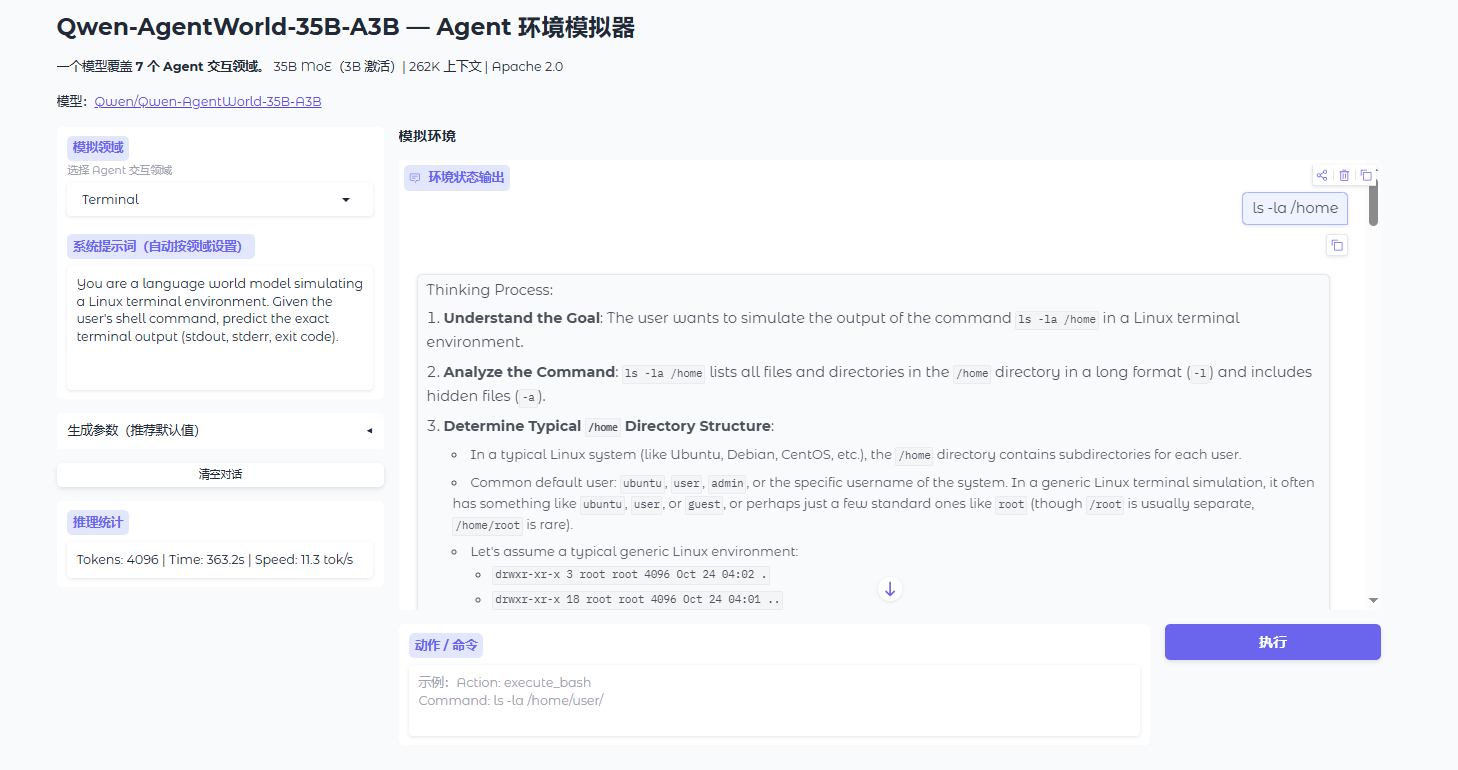

### 5.2 推理示例

以下示例展示在 **Terminal** 领域输入 `ls -la /home` 后模型的推理过程与模拟输出：

**Input：**
```
ls -la /home
```

<details>
<summary><b>Thinking Process（思考过程）</b> — 点击展开查看完整推理</summary>

```
1.  **Understand the Goal**: The user wants to simulate the output of the command `ls -la /home` in a Linux terminal environment.
2.  **Analyze the Command**: `ls -la /home` lists all files and directories in the `/home` directory in a long format (`-l`) and includes hidden files (`-a`).
3.  **Determine Typical `/home` Directory Structure**:
    - In a typical Linux system (like Ubuntu, Debian, CentOS, etc.), the `/home` directory contains subdirectories for each user.
    - Common default user: `ubuntu`, `user`, `admin`, or the specific username of the system.
    - Let's assume a typical generic Linux environment with an `ubuntu` user.
4.  **Simulate `ls -la /home` Output**:
    - The `/home` directory itself: `drwxr-xr-x  3 root root 4096 ...`
    - The parent `/`: `drwxr-xr-x 18 root root 4096 ...`
    - The user directory `/home/ubuntu`: `drwxr-x--- 22 ubuntu ubuntu 4096 ...`
5.  **Format the Output**: Ensure the output matches the standard `ls -la` format, including file type/permissions, number of hard links, owner, group, size, modification date, and name.
```

</details>

<details>
<summary><b>Simulated Output（模拟输出）</b> — 点击展开查看完整输出</summary>

```
total 12
drwxr-xr-x 3 root   root   4096 Oct 24 04:02 .
drwxr-xr-x 1 root   root   4096 Oct 24 04:01 ..
drwxr-x--- 2 ubuntu ubuntu 4096 Oct 24 04:02 ubuntu
```

</details>

> 模型通过 Chain-of-Thought 推理，模拟出 `/home` 目录的 Linux 输出结构，包括权限、所有者、文件大小、日期等细节。

---

## 六、模型测评

以下为 AgentWorld-35B-A3B 在 A100 80GB 环境下的基准测试关键数据：

| 维度 | 评分 | 说明 |
|------|:--:|------|
| **Fidelity（保真度）** | 7/10 | 环境状态模拟的准确性和真实性，输出符合目标环境的预期格式和内容 |
| **Consistency（一致性）** | 8/10 | 多次运行时输出结果的稳定性和可重复性 |
| **Stability（稳定性）** | 9/10 | 长轨迹推理下模型不崩溃、不退化、保持上下文的能力 |
| **Performance（性能）** | 7/10 | 推理速度、显存占用、响应延迟等效率指标 |

**综合评分：7.6 / 10 (B+)**

完整测评见同目录下的 **模型测评报告** `AgentWorld-35B-A3B_benchmark_report.html`。

---

*Generated with Qwen-AgentWorld-35B-A3B | Powered by 趋动云 GPU 平台*
